# 08a — ESM-2 Peptide Sequence Scoring

## Pipeline 4 — Protein Language Models and AI-guided Peptide Design

This notebook introduces **ESM-2** into PEARL.

Core candidates:

```text
F0010 = IGERCQYRDLK
CF06  = IGERCQYRELR
CF02  = IGERSQYRELK
```

Goals:
- masked pseudo-log-likelihood (PLL);
- pseudo-perplexity;
- position-wise support;
- ESM-2 embeddings;
- integration with 07d/07e.

**Important:** ESM-2 is used here as a sequence-plausibility prior, not as a binding-affinity predictor.


## 1. Environment check

In [1]:
import sys
from pathlib import Path
print("Python:", sys.version)
print("Working directory:", Path.cwd())

try:
    import torch
    print("PyTorch:", torch.__version__)
except Exception as exc:
    raise RuntimeError(f"PyTorch unavailable: {exc}")

try:
    import esm
    print("fair-esm import: OK")
except Exception:
    print("Install once with: pip install fair-esm")
    raise


Python: 3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]
Working directory: /Users/robertobruzzese/Desktop/venv
PyTorch: 2.13.0
fair-esm import: OK


### Recommended environment

```bash
conda create -n pearl-ai python=3.11 -y
conda activate pearl-ai
pip install torch fair-esm pandas numpy matplotlib scikit-learn jupyter ipykernel
python -m ipykernel install --user --name pearl-ai --display-name "Python (PEARL AI)"
```


## 2. Imports

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
print("Imports OK")


Imports OK


## 3. Device

In [3]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print("Device:", DEVICE)


Device: mps


## 4. Configuration

In [4]:
MODEL_NAME = "esm2_t6_8M_UR50D"

REFERENCE_SEQUENCES = {
    "F0010": "IGERCQYRDLK",
    "CF06": "IGERCQYRELR",
    "CF02": "IGERSQYRELK",
}

SEED_NAME = "F0010"
SEED_SEQUENCE = REFERENCE_SEQUENCES[SEED_NAME]

OUTPUT_ROOT = Path("outputs") / "pipeline_4_ai_08a_esm2_sequence_scoring"
TABLE_DIR = OUTPUT_ROOT / "tables"
REPORT_DIR = OUTPUT_ROOT / "reports"
for d in [OUTPUT_ROOT, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Model:", MODEL_NAME)
print("Output:", OUTPUT_ROOT.resolve())


Model: esm2_t6_8M_UR50D
Output: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08a_esm2_sequence_scoring


## 5. Core candidate set

In [5]:
core_candidates_df = pd.DataFrame([
    {"candidate": name, "sequence": seq, "source": "core_PEARL_selection"}
    for name, seq in REFERENCE_SEQUENCES.items()
])
display(core_candidates_df)


,candidate,sequence,source
0,F0010,IGERCQYRDLK,core_PEARL_selection
1,CF06,IGERCQYRELR,core_PEARL_selection
2,CF02,IGERSQYRELK,core_PEARL_selection


## 6. Optional Direct CLEAR import

In [6]:
CLEAR_CANDIDATE_FILES = [
    Path("outputs/clear_peptide_counterfactual_optimization_04e/successful_counterfactuals.csv"),
    Path("outputs/clear_peptide_counterfactual_optimization_04e/clear_successful_counterfactuals.csv"),
    Path("outputs/clear_counterfactual_optimization_04e/successful_counterfactuals.csv"),
]

clear_file = next((p for p in CLEAR_CANDIDATE_FILES if p.exists()), None)
clear_candidates_df = None

if clear_file is None:
    print("No Direct CLEAR CSV found automatically.")
else:
    raw_clear = pd.read_csv(clear_file)
    print("Using:", clear_file)
    print("Columns:", list(raw_clear.columns))
    sequence_col = next((c for c in [
        "sequence", "cf_sequence", "counterfactual_sequence", "peptide_sequence"
    ] if c in raw_clear.columns), None)

    if sequence_col is None:
        print("No sequence column identified; CLEAR import skipped.")
    else:
        clear_candidates_df = pd.DataFrame({
            "candidate": [f"CLEAR_{i+1:03d}" for i in range(len(raw_clear))],
            "sequence": raw_clear[sequence_col].astype(str),
            "source": "Direct_CLEAR_04e",
        }).drop_duplicates("sequence").reset_index(drop=True)
        print("Loaded CLEAR sequences:", len(clear_candidates_df))


No Direct CLEAR CSV found automatically.


## 7. Final valid sequence set

In [7]:
frames = [core_candidates_df]
if clear_candidates_df is not None:
    frames.append(clear_candidates_df)

all_candidates_df = pd.concat(frames, ignore_index=True)
VALID_AA = set("ACDEFGHIKLMNPQRSTVWY")
all_candidates_df["valid_sequence"] = all_candidates_df["sequence"].apply(
    lambda s: len(s) > 0 and set(s).issubset(VALID_AA)
)
all_candidates_df = (
    all_candidates_df[all_candidates_df["valid_sequence"]]
    .drop_duplicates("sequence")
    .reset_index(drop=True)
)
print("Unique valid sequences:", len(all_candidates_df))
display(all_candidates_df.head(20))


Unique valid sequences: 3


,candidate,sequence,source,valid_sequence
0,F0010,IGERCQYRDLK,core_PEARL_selection,True
1,CF06,IGERCQYRELR,core_PEARL_selection,True
2,CF02,IGERSQYRELK,core_PEARL_selection,True


## 8. Load ESM-2

In [8]:
if MODEL_NAME == "esm2_t6_8M_UR50D":
    model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
elif MODEL_NAME == "esm2_t12_35M_UR50D":
    model, alphabet = esm.pretrained.esm2_t12_35M_UR50D()
else:
    raise ValueError(MODEL_NAME)

model = model.eval().to(DEVICE)
batch_converter = alphabet.get_batch_converter()
MASK_IDX = alphabet.mask_idx

print("Loaded:", MODEL_NAME)
print("Layers:", model.num_layers)
print("Embedding dimension:", model.embed_dim)


Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm2_t6_8M_UR50D.pt" to /Users/robertobruzzese/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm2_t6_8M_UR50D-contact-regression.pt" to /Users/robertobruzzese/.cache/torch/hub/checkpoints/esm2_t6_8M_UR50D-contact-regression.pt
Loaded: esm2_t6_8M_UR50D
Layers: 6
Embedding dimension: 320


## 9. Masked pseudo-log-likelihood

In [9]:
@torch.no_grad()
def esm2_masked_pll(sequence, label="peptide"):
    _, _, tokens = batch_converter([(label, sequence)])
    tokens = tokens.to(DEVICE)

    pos_log_probs = []
    for pos in range(1, len(sequence) + 1):
        masked = tokens.clone()
        true_token = int(tokens[0, pos].item())
        masked[0, pos] = MASK_IDX

        result = model(masked, repr_layers=[], return_contacts=False)
        logits = result["logits"][0, pos]
        log_probs = torch.log_softmax(logits, dim=-1)

        pos_log_probs.append(float(log_probs[true_token].detach().cpu().item()))

    pll_sum = float(np.sum(pos_log_probs))
    pll_mean = float(np.mean(pos_log_probs))
    pseudo_perplexity = float(np.exp(-pll_mean))

    return pll_sum, pll_mean, pseudo_perplexity, pos_log_probs


## 10. Score candidates

In [10]:
score_rows = []
position_rows = []

for idx, row in all_candidates_df.iterrows():
    name, seq = row["candidate"], row["sequence"]
    pll_sum, pll_mean, pppl, pos_probs = esm2_masked_pll(seq, name)

    score_rows.append({
        "candidate": name,
        "sequence": seq,
        "source": row["source"],
        "length": len(seq),
        "ESM2_PLL_sum": pll_sum,
        "ESM2_PLL_mean": pll_mean,
        "ESM2_pseudo_perplexity": pppl,
    })

    for pos, (aa, lp) in enumerate(zip(seq, pos_probs), start=1):
        position_rows.append({
            "candidate": name,
            "sequence": seq,
            "position": pos,
            "aa": aa,
            "ESM2_masked_log_prob": lp,
        })

    print(f"{idx+1}/{len(all_candidates_df)} {name}: mean PLL={pll_mean:.4f}")

esm2_scores_df = pd.DataFrame(score_rows)
position_scores_df = pd.DataFrame(position_rows)

esm2_scores_df.to_csv(TABLE_DIR / "08a_ESM2_sequence_scores.csv", index=False)
position_scores_df.to_csv(TABLE_DIR / "08a_ESM2_position_scores.csv", index=False)


1/3 F0010: mean PLL=-3.2402
2/3 CF06: mean PLL=-3.2316
3/3 CF02: mean PLL=-3.1201


## 11. Ranking

In [11]:
ranking_df = esm2_scores_df.sort_values("ESM2_PLL_mean", ascending=False).reset_index(drop=True)
ranking_df.insert(0, "ESM2_rank", np.arange(len(ranking_df)) + 1)
ranking_df.to_csv(TABLE_DIR / "08a_ESM2_ranking.csv", index=False)
display(ranking_df.head(30))


,ESM2_rank,candidate,sequence,source,length,ESM2_PLL_sum,ESM2_PLL_mean,ESM2_pseudo_perplexity
0,1,CF02,IGERSQYRELK,core_PEARL_selection,11,-34.320967,-3.120088,22.648371
1,2,CF06,IGERCQYRELR,core_PEARL_selection,11,-35.547928,-3.231630,25.320893
2,3,F0010,IGERCQYRDLK,core_PEARL_selection,11,-35.641986,-3.240181,25.538332


## 12. Core candidates

In [12]:
core_score_df = (
    esm2_scores_df[esm2_scores_df["candidate"].isin(REFERENCE_SEQUENCES)]
    .copy()
    .sort_values("ESM2_PLL_mean", ascending=False)
)

seed_pll = float(core_score_df.loc[
    core_score_df["candidate"] == SEED_NAME, "ESM2_PLL_mean"
].iloc[0])

core_score_df["delta_PLL_mean_vs_F0010"] = core_score_df["ESM2_PLL_mean"] - seed_pll
display(core_score_df)


,candidate,sequence,source,length,ESM2_PLL_sum,ESM2_PLL_mean,ESM2_pseudo_perplexity,delta_PLL_mean_vs_F0010
2,CF02,IGERSQYRELK,core_PEARL_selection,11,-34.320967,-3.120088,22.648371,0.120093
1,CF06,IGERCQYRELR,core_PEARL_selection,11,-35.547928,-3.231630,25.320893,0.008551
0,F0010,IGERCQYRDLK,core_PEARL_selection,11,-35.641986,-3.240181,25.538332,0.000000


## 13. Core PLL plot

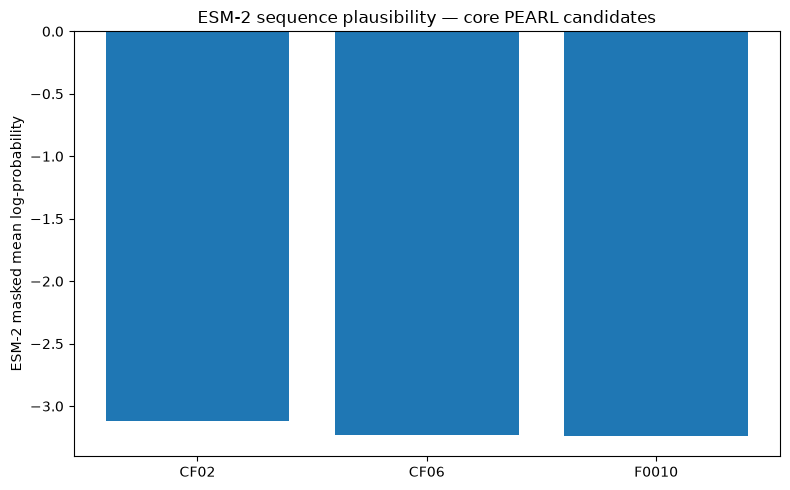

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(core_score_df["candidate"], core_score_df["ESM2_PLL_mean"])
plt.ylabel("ESM-2 masked mean log-probability")
plt.title("ESM-2 sequence plausibility — core PEARL candidates")
plt.tight_layout()
plt.savefig(REPORT_DIR / "core_candidate_PLL_comparison.png", dpi=250, bbox_inches="tight")
plt.show()


## 14. Position-wise support

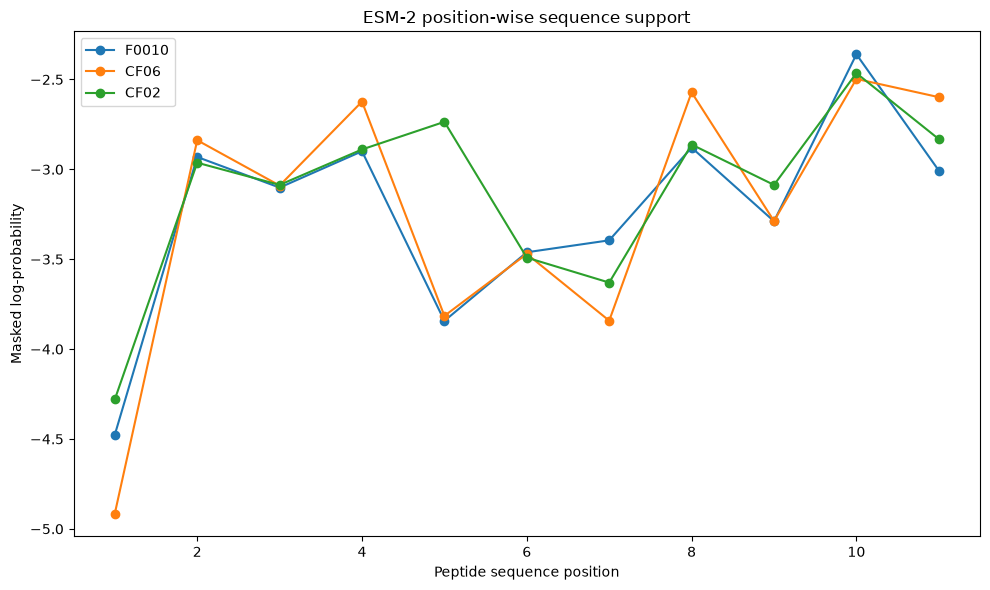

In [14]:
core_positions_df = position_scores_df[
    position_scores_df["candidate"].isin(REFERENCE_SEQUENCES)
].copy()

plt.figure(figsize=(10, 6))
for name in ["F0010", "CF06", "CF02"]:
    df = core_positions_df[core_positions_df["candidate"] == name]
    plt.plot(df["position"], df["ESM2_masked_log_prob"], marker="o", label=name)

plt.xlabel("Peptide sequence position")
plt.ylabel("Masked log-probability")
plt.title("ESM-2 position-wise sequence support")
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "core_candidate_position_PLL.png", dpi=250, bbox_inches="tight")
plt.show()


## 15. Mutation-site interpretation

In [15]:
MUTATIONS = {
    "CF06": {9: ("D", "E"), 11: ("K", "R")},
    "CF02": {5: ("C", "S"), 9: ("D", "E")},
}

mutation_rows = []
for candidate, mutations in MUTATIONS.items():
    for pos, (seed_aa, mutant_aa) in mutations.items():
        seed_row = core_positions_df[
            (core_positions_df["candidate"] == "F0010")
            & (core_positions_df["position"] == pos)
        ].iloc[0]

        mutant_row = core_positions_df[
            (core_positions_df["candidate"] == candidate)
            & (core_positions_df["position"] == pos)
        ].iloc[0]

        mutation_rows.append({
            "candidate": candidate,
            "position": pos,
            "F0010_aa": seed_aa,
            "mutant_aa": mutant_aa,
            "F0010_log_prob": seed_row["ESM2_masked_log_prob"],
            "mutant_log_prob": mutant_row["ESM2_masked_log_prob"],
            "delta_log_prob_mutant_minus_F0010":
                mutant_row["ESM2_masked_log_prob"] - seed_row["ESM2_masked_log_prob"],
        })

mutation_support_df = pd.DataFrame(mutation_rows)
mutation_support_df.to_csv(TABLE_DIR / "08a_mutation_site_ESM2_support.csv", index=False)
display(mutation_support_df)


,candidate,position,F0010_aa,mutant_aa,F0010_log_prob,mutant_log_prob,delta_log_prob_mutant_minus_F0010
0,CF06,9,D,E,-3.288833,-3.287394,0.001440
1,CF06,11,K,R,-3.006787,-2.598379,0.408408
2,CF02,5,C,S,-3.842895,-2.735696,1.107199
3,CF02,9,D,E,-3.288833,-3.086671,0.202162


## 16. Embeddings

In [16]:
@torch.no_grad()
def esm2_embedding(sequence, label="peptide"):
    _, _, tokens = batch_converter([(label, sequence)])
    tokens = tokens.to(DEVICE)

    result = model(
        tokens,
        repr_layers=[model.num_layers],
        return_contacts=False,
    )

    reps = result["representations"][model.num_layers][0, 1:len(sequence)+1, :]
    return reps.mean(dim=0).detach().cpu().numpy()


In [17]:
embedding_matrix = np.vstack([
    esm2_embedding(row["sequence"], row["candidate"])
    for _, row in all_candidates_df.iterrows()
])

embedding_metadata_df = all_candidates_df[["candidate", "sequence", "source"]].copy()

np.save(TABLE_DIR / "08a_ESM2_embeddings.npy", embedding_matrix)
embedding_metadata_df.to_csv(TABLE_DIR / "08a_ESM2_embedding_metadata.csv", index=False)

print("Embedding matrix:", embedding_matrix.shape)


Embedding matrix: (3, 320)


## 17. Similarity to F0010

In [18]:
seed_idx = int(
    embedding_metadata_df.index[
        embedding_metadata_df["candidate"] == SEED_NAME
    ][0]
)

similarities = cosine_similarity(
    embedding_matrix,
    embedding_matrix[seed_idx:seed_idx+1]
).ravel()

embedding_similarity_df = embedding_metadata_df.copy()
embedding_similarity_df["cosine_similarity_to_F0010"] = similarities
embedding_similarity_df = embedding_similarity_df.sort_values(
    "cosine_similarity_to_F0010", ascending=False
)
embedding_similarity_df.to_csv(
    TABLE_DIR / "08a_embedding_similarity_to_F0010.csv", index=False
)
display(embedding_similarity_df.head(30))


,candidate,sequence,source,cosine_similarity_to_F0010
0,F0010,IGERCQYRDLK,core_PEARL_selection,1.000000
1,CF06,IGERCQYRELR,core_PEARL_selection,0.992827
2,CF02,IGERSQYRELK,core_PEARL_selection,0.990478


## 18. PCA

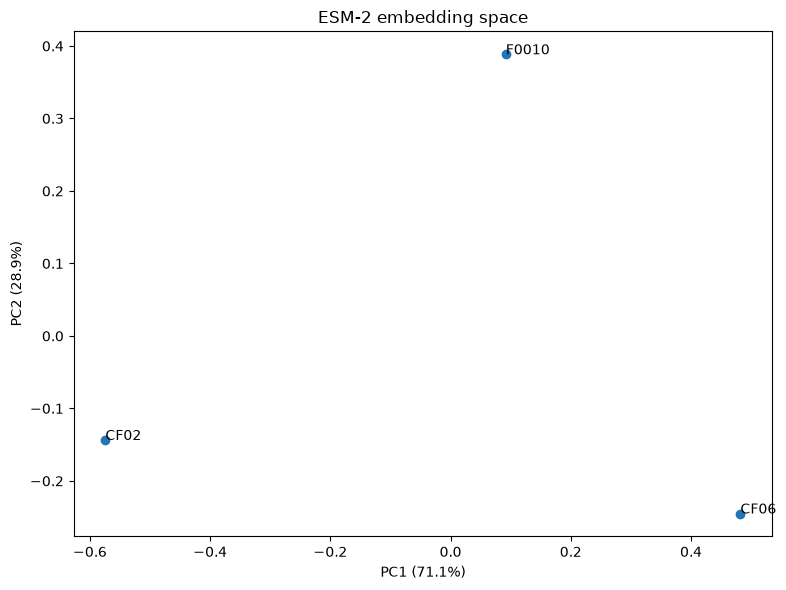

In [19]:
if len(embedding_matrix) >= 3:
    pca = PCA(n_components=2)
    coords = pca.fit_transform(embedding_matrix)

    pca_df = embedding_metadata_df.copy()
    pca_df["PC1"] = coords[:, 0]
    pca_df["PC2"] = coords[:, 1]
    pca_df.to_csv(TABLE_DIR / "08a_ESM2_embedding_PCA.csv", index=False)

    plt.figure(figsize=(8, 6))
    plt.scatter(pca_df["PC1"], pca_df["PC2"])

    for name in ["F0010", "CF06", "CF02"]:
        row = pca_df[pca_df["candidate"] == name]
        if len(row):
            plt.annotate(name, (row["PC1"].iloc[0], row["PC2"].iloc[0]))

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    plt.title("ESM-2 embedding space")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / "ESM2_embedding_PCA.png", dpi=250, bbox_inches="tight")
    plt.show()


## 19. Integrate 07d / 07e

In [20]:
DYNAMIC_FILE = (
    Path("outputs")
    / "pipeline_3_md_07d_selected_peptide_comparison"
    / "production_1ns"
    / "07d_selected_peptide_MD_comparison.csv"
)

ENERGY_FILE = (
    Path("outputs")
    / "pipeline_3_md_07e_mmgbsa_endpoint_comparison"
    / "tables"
    / "07e_endpoint_energy_summary.csv"
)

integration_df = core_score_df[
    ["candidate", "sequence", "ESM2_PLL_mean", "ESM2_pseudo_perplexity", "delta_PLL_mean_vs_F0010"]
].copy()

if DYNAMIC_FILE.exists():
    dyn = pd.read_csv(DYNAMIC_FILE)
    keep = [c for c in [
        "candidate", "mean_D_CA_RMSD_A", "mean_D_CA_RMSF_A",
        "n_persistent_contacts_50pct", "mean_contact_persistence"
    ] if c in dyn.columns]
    integration_df = integration_df.merge(dyn[keep], on="candidate", how="left")

if ENERGY_FILE.exists():
    ene = pd.read_csv(ENERGY_FILE)
    keep = [c for c in [
        "candidate", "energetic_rank", "mean_delta_E_endpoint_kcal_mol"
    ] if c in ene.columns]
    integration_df = integration_df.merge(ene[keep], on="candidate", how="left")

integration_df.to_csv(TABLE_DIR / "08a_ESM2_MD_endpoint_integration.csv", index=False)
display(integration_df)


,candidate,sequence,ESM2_PLL_mean,ESM2_pseudo_perplexity,delta_PLL_mean_vs_F0010,mean_D_CA_RMSD_A,mean_D_CA_RMSF_A,n_persistent_contacts_50pct,mean_contact_persistence,energetic_rank,mean_delta_E_endpoint_kcal_mol
0,CF02,IGERSQYRELK,-3.120088,22.648371,0.120093,0.901385,0.737052,43,0.602886,3,-56.619600
1,CF06,IGERCQYRELR,-3.231630,25.320893,0.008551,1.293427,0.903728,45,0.528545,1,-65.661216
2,F0010,IGERCQYRDLK,-3.240181,25.538332,0.000000,1.965916,1.163706,43,0.540519,2,-59.457704


## 20. Automatic report

In [21]:
core_ranked = core_score_df.sort_values("ESM2_PLL_mean", ascending=False)

report_lines = [
    "# 08a - ESM-2 Peptide Sequence Scoring",
    "",
    f"- Model: {MODEL_NAME}",
    f"- Device: {DEVICE}",
    f"- Total sequences scored: {len(esm2_scores_df)}",
    "",
    "## Core candidate ranking",
]

for rank, row in enumerate(core_ranked.itertuples(), start=1):
    report_lines.append(
        f"{rank}. {row.candidate} ({row.sequence}): "
        f"mean PLL={row.ESM2_PLL_mean:.4f}; "
        f"pseudo-perplexity={row.ESM2_pseudo_perplexity:.4f}"
    )

report_lines += [
    "",
    "## Interpretation",
    "ESM-2 is used as a pretrained sequence-plausibility prior, not as a receptor-binding score.",
    "The strongest evidence comes from convergence with structural, MD and endpoint-energy criteria.",
]

report_text = "\n".join(report_lines)
report_path = REPORT_DIR / "08a_ESM2_sequence_scoring_report.md"
report_path.write_text(report_text, encoding="utf-8")

print(report_text)
print("\nReport:", report_path.resolve())


# 08a - ESM-2 Peptide Sequence Scoring

- Model: esm2_t6_8M_UR50D
- Device: mps
- Total sequences scored: 3

## Core candidate ranking
1. CF02 (IGERSQYRELK): mean PLL=-3.1201; pseudo-perplexity=22.6484
2. CF06 (IGERCQYRELR): mean PLL=-3.2316; pseudo-perplexity=25.3209
3. F0010 (IGERCQYRDLK): mean PLL=-3.2402; pseudo-perplexity=25.5383

## Interpretation
ESM-2 is used as a pretrained sequence-plausibility prior, not as a receptor-binding score.
The strongest evidence comes from convergence with structural, MD and endpoint-energy criteria.

Report: /Users/robertobruzzese/Desktop/venv/outputs/pipeline_4_ai_08a_esm2_sequence_scoring/reports/08a_ESM2_sequence_scoring_report.md


# 21. Next step

The next notebook will be:

```text
08b_ProteinMPNN_Structure_Conditioned_Peptide_Design.ipynb
```

ProteinMPNN will use the receptor–peptide structure to generate structure-conditioned peptide variants while keeping receptor chain B fixed and controlling which positions of chain D can mutate.
